# Exploration

Some dataset inspection because EDA was done on kaggle

In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)

In [4]:
current = pd.Series([12,21,43,11,67])
previous = pd.Series([11,0,2,55,0])

# If previous is 0, check if current is also 0. 
# If both are 0, change is 0. If current > 0, cap the change at 1.0 (100% jump)
pct_change = np.where(
    previous == 0,
    np.where(current == 0, 0.0, 1.0), 
    (current - previous) / previous
)

In [5]:
pct_change

array([ 0.09090909,  1.        , 20.5       , -0.8       ,  1.        ])

In [2]:
def read_dataset(filepath):
    df = pd.read_csv(filepath)
    return df

In [3]:
train_df = read_dataset("Train.csv")

In [4]:
train_df.head()

,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,m2_paybill_companies,m3_paybill_volume,m3_paybill_total_value,m3_paybill_highest_amount,m3_paybill_companies,m4_paybill_volume,m4_paybill_total_value,m4_paybill_highest_amount,m4_paybill_companies,m5_paybill_volume,m5_paybill_total_value,m5_paybill_highest_amount,m5_paybill_companies,m6_paybill_volume,m6_paybill_total_value,m6_paybill_highest_amount,m6_paybill_companies,m1_merchantpay_volume,m1_merchantpay_total_value,m1_merchantpay_highest_amount,m1_merchantpay_merchants,m2_merchantpay_volume,m2_merchantpay_total_value,m2_merchantpay_highest_amount,m2_merchantpay_merchants,m3_merchantpay_volume,m3_merchantpay_total_value,m3_merchantpay_highest_amount,m3_merchantpay_merchants,m4_merchantpay_volume,m4_merchantpay_total_value,m4_merchantpay_highest_amount,m4_merchantpay_merchants,m5_merchantpay_volume,m5_merchantpay_total_value,m5_merchantpay_highest_amount,m5_merchantpay_merchants,m6_merchantpay_volume,m6_merchantpay_total_value,m6_merchantpay_highest_amount,m6_merchantpay_merchants,m1_transfer_from_bank_volume,m1_transfer_from_bank_total_value,m1_transfer_from_bank_highest_amount,m1_transfer_from_bank_banks,m2_transfer_from_bank_volume,m2_transfer_from_bank_total_value,m2_transfer_from_bank_highest_amount,m2_transfer_from_bank_banks,m3_transfer_from_bank_volume,m3_transfer_from_bank_total_value,m3_transfer_from_bank_highest_amount,m3_transfer_from_bank_banks,m4_transfer_from_bank_volume,m4_transfer_from_bank_total_value,m4_transfer_from_bank_highest_amount,m4_transfer_from_bank_banks,m5_transfer_from_bank_volume,m5_transfer_from_bank_total_value,m5_transfer_from_bank_highest_amount,m5_transfer_from_bank_banks,m6_transfer_from_bank_volume,m6_transfer_from_bank_total_value,m6_transfer_from_bank_highest_amount,m6_transfer_from_bank_banks,m1_mm_send_volume,m1_mm_send_total_value,m1_mm_send_highest_amount,m1_mm_send_recipients,m2_mm_send_volume,m2_mm_send_total_value,m2_mm_send_highest_amount,m2_mm_send_recipients,m3_mm_send_volume,m3_mm_send_total_value,m3_mm_send_highest_amount,m3_mm_send_recipients,m4_mm_send_volume,m4_mm_send_total_value,m4_mm_send_highest_amount,m4_mm_send_recipients,m5_mm_send_volume,m5_mm_send_total_value,m5_mm_send_highest_amount,m5_mm_send_recipients,m6_mm_send_volume,m6_mm_send_total_value,m6_mm_send_highest_amount,m6_mm_send_recipients,m1_received_volume,m1_received_total_value,m1_received_highest_amount,m1_received_senders,m2_received_volume,m2_received_total_value,m2_received_highest_amount,m2_received_senders,m3_received_volume,m3_received_total_value,m3_received_highest_amount,m3_received_senders,m4_received_volume,m4_received_total_value,m4_received_highest_amount,m4_received_senders,m5_received_volume,m5_received_total_value,m5_received_highest_amount,m5_received_senders,m6_received_volume,m6_received_total_value,m6_received_highest_amount,m6_received_senders,m1_deposit_volume,m1_deposit_total_value,m1_deposit_highest_amount,m1_deposit_agents,m2_deposit_volume,m2_deposit_total_value,m2_deposit_highest_amount,m2_deposit_agents,m3_deposit_volume,m3_deposit_total_value,m3_deposit_highest_amount,m3_deposit_agents,m4_deposit_volume,m4_deposit_total_value,m4_deposit_highest_amount,m4_deposit_agents,m5_deposit_volume,m5_deposit_total_value,m5_deposit_highest_amount,m5_deposit_agents,m6_deposit_volume,m6_deposit_total_value,m6_deposit_highest_amount,m6_deposit_agents,m1_withdraw_volume,m1_withdraw_total_value,m1_withdraw_highest_amount,m1_withdraw_agents,m2_withdraw_volume,m2_withdraw_total_value,m2_withdraw_highest_amount,m2_withdraw_agents,m3_withdraw_volume,m3_withdraw_total_value,m3_withdraw_highest_amount,m3_withdraw_agents,m4_withdraw_volume,m4_withdraw_total_value,m4_withdraw_highest_amount,m4_withdraw_agents,m5_withdraw_volume,m5_withdraw_total_value,m5_withdraw_highe

In [148]:
def get_bills_cols(df):
    # List of target keywords you want to look for in the middle
    keywords = [r'.+paybill_total_value$', r'.+paybill_highest_amount$']
    
    # Combine them into: .+(?:_paybill_|_invoice_|_receipt_).+
    # The parenthesis () capture the specific keyword that matched
    pattern = rf'(?P<matched_keyword>{"|".join(keywords)})'

    # Dataframe columns
    df_cols = train_df.columns.to_list()
    matched_cols = []
    for s in df_cols:
        match = re.search(pattern, s)
        if match:
            # Extract the specific keyword that triggered the match
            keyword_found = match.group("matched_keyword")
            # print(f"Match found! String: '{s}' | Keyword: '{keyword_found}'")
            matched_cols.append(keyword_found)
        else:
            pass
    
    return matched_cols

In [149]:
bill_cols = get_bills_cols(train_df)
bill_cols

['m1_paybill_total_value',
 'm1_paybill_highest_amount',
 'm2_paybill_total_value',
 'm2_paybill_highest_amount',
 'm3_paybill_total_value',
 'm3_paybill_highest_amount',
 'm4_paybill_total_value',
 'm4_paybill_highest_amount',
 'm5_paybill_total_value',
 'm5_paybill_highest_amount',
 'm6_paybill_total_value',
 'm6_paybill_highest_amount']

<Axes: >

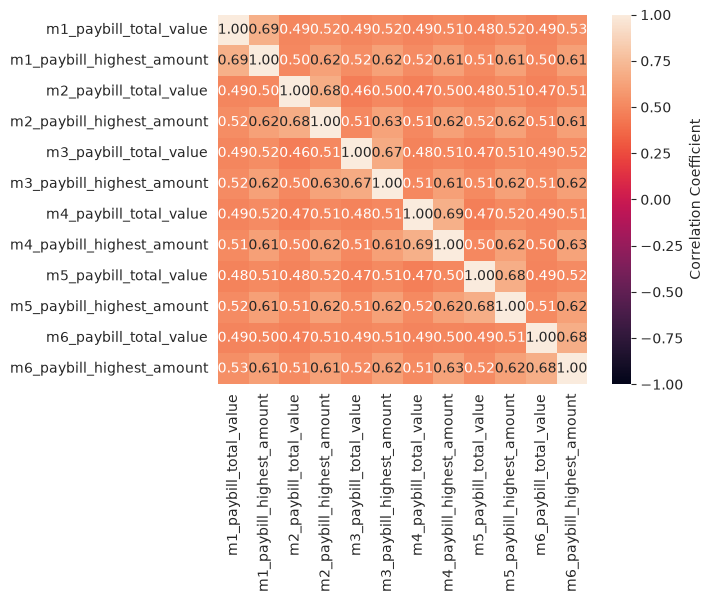

In [150]:
sns.heatmap(
    train_df[bill_cols].corr(method='pearson'),
    annot=True,
      fmt='.2f',
      # cmap='coolwarm',
      vmin=-1,
      vmax=1,
      square=True,
      cbar_kws={'label': 'Correlation Coefficient'},
)

In [151]:
def calculate_vif(df: pd.DataFrame, features: list) -> pd.DataFrame:
  # Filter and drop missing values or fill with 0
  X = df[features].dropna()

  # Create DataFrame to store VIF results
  vif_data = pd.DataFrame()
  vif_data['Feature'] = features

  # Calculate VIF for each column
  vif_data['VIF'] = [
      variance_inflation_factor(X.values, i) for i in range(X.shape[1])
  ]

  return vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)

In [152]:
vif_df = calculate_vif(train_df, bill_cols)

In [153]:
vif_df[vif_df['VIF'] < 5]

,Feature,VIF
0,m4_paybill_highest_amount,3.217015
1,m6_paybill_highest_amount,3.198640
2,m2_paybill_highest_amount,3.184662
3,m5_paybill_highest_amount,3.169660
4,m1_paybill_highest_amount,3.155227
5,m3_paybill_highest_amount,3.137400
6,m1_paybill_total_value,2.288270
7,m4_paybill_total_value,2.270431
8,m6_paybill_total_value,2.233595
9,m5_paybill_total_value,2.203361


In [154]:
def plot_paybill_grid(df: pd.DataFrame, log_monetary: bool = True):
  """Plots individual distribution histograms for all 24 Paybill columns

  across 6 months (M1 to M6).

  Parameters:
  -----------
  df : pd.DataFrame
      The dataset containing paybill features.
  log_monetary : bool, default=True
      Applies log1p transformation to monetary values to handle right skew.
  """
  months = [f"m{i}" for i in range(1, 7)]
  metrics = ["volume", "total_value", "highest_amount", "companies"]

  fig, axes = plt.subplots(6, 4, figsize=(20, 18))
  fig.suptitle(
      "Paybill Feature Distributions Across 6 Months (M1 = Recent, M6 ="
      " Oldest)",
      fontsize=16,
      y=1.02,
  )

  for row_idx, m in enumerate(months):
    for col_idx, metric in enumerate(metrics):
      col_name = f"{m}_paybill_{metric}"
      ax = axes[row_idx, col_idx]

      if col_name in df.columns:
        data = df[col_name].dropna()

        # Handle extreme skewness in financial values
        if log_monetary and metric in ["total_value", "highest_amount"]:
          sns.histplot(
              np.log1p(data), ax=ax, kde=True, color="teal", bins=30
          )
          ax.set_xlabel(f"log1p({col_name})")
        else:
          sns.histplot(
              data,
              ax=ax,
              kde=True,
              color="skyblue" if metric == "volume" else "purple",
              bins=20,
          )
          ax.set_xlabel(col_name)

        ax.set_ylabel("Count")
        ax.set_title(
            f"{m.upper()} - {metric.replace('_', ' ').title()}", fontsize=10
        )
      else:
        ax.text(
            0.5,
            0.5,
            f"Column '{col_name}'\nnot found",
            ha="center",
            va="center",
        )

  plt.tight_layout()
  plt.show()

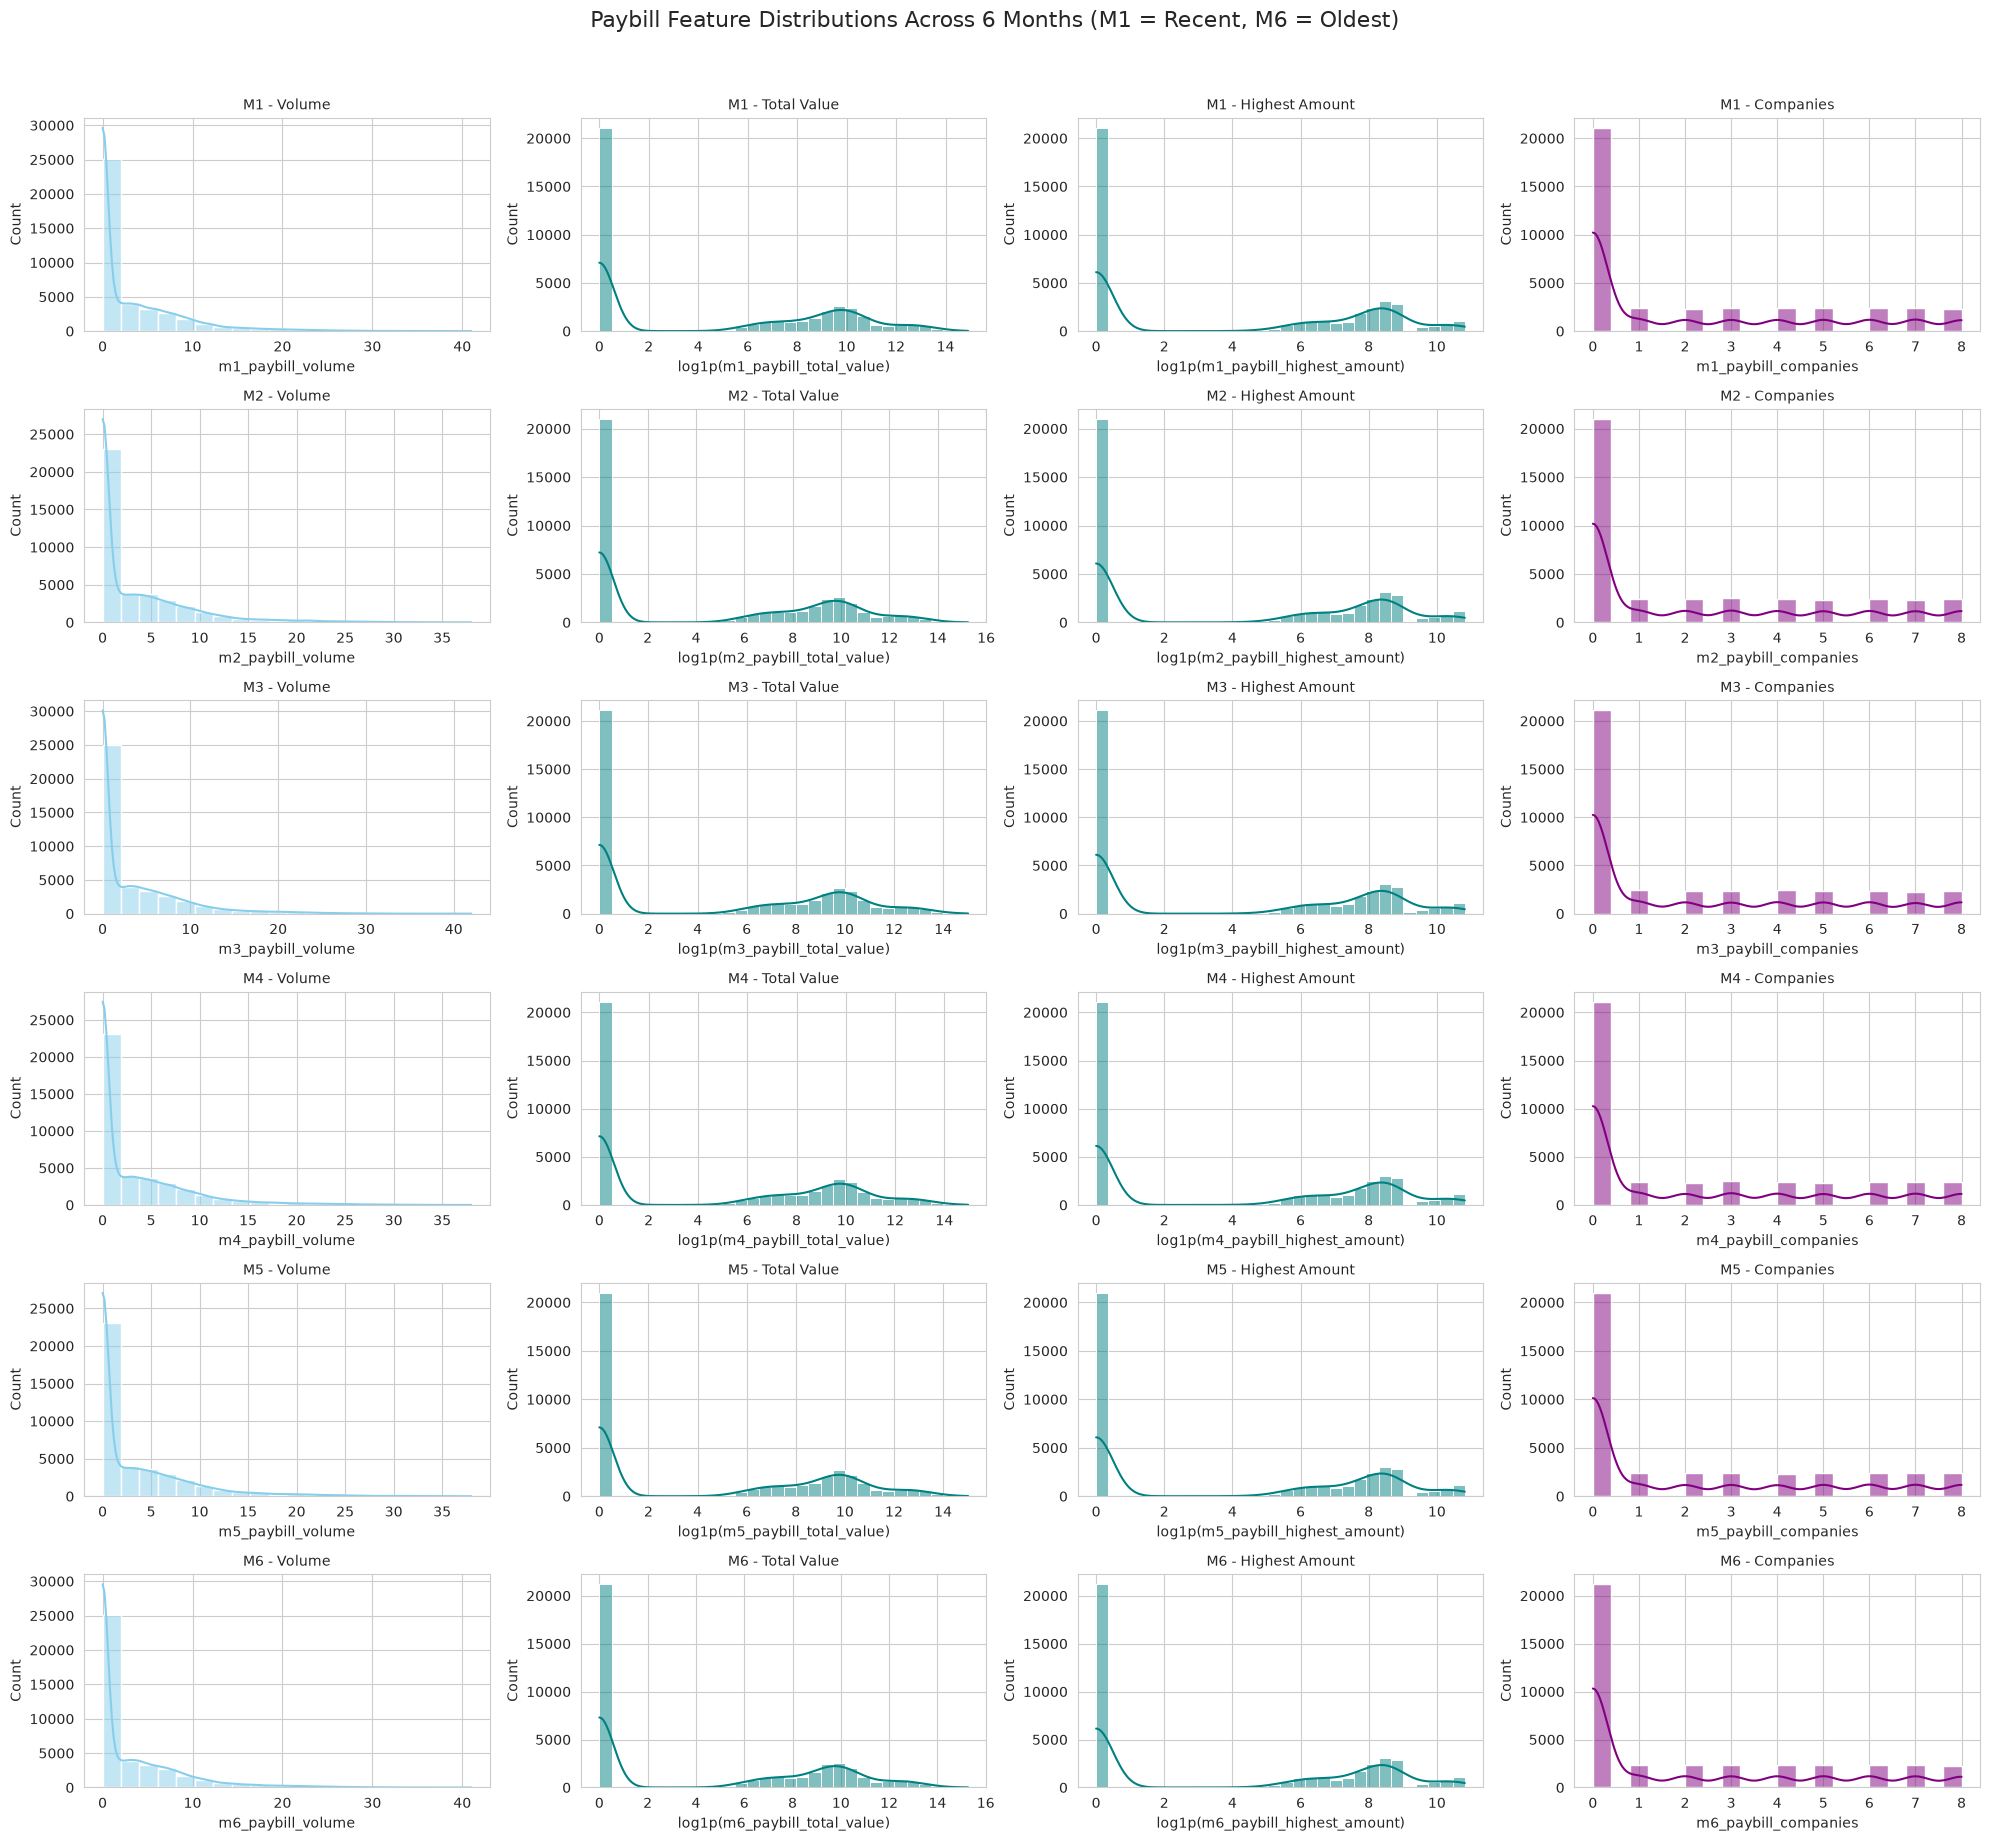

In [155]:
plot_paybill_grid(train_df)

In [156]:
def Feature_Engineering_Pipeline(df: pd.DataFrame) -> pd.DataFrame:
  features = pd.DataFrame(index=df.index)

  months = [f"m{i}" for i in range(1, 7)]

  # 1. Profile & Activity Signals
  features["arpu"] = df["arpu"]
  features["x_90_d_activity_rate"] = df["x_90_d_activity_rate"]

  # 2. Daily Average Balance Features
  bal_cols = [f"{m}_daily_avg_bal" for m in months]
  features["avg_daily_bal_6m"] = df[bal_cols].mean(axis=1)
  features["bal_recency_ratio"] = df["m1_daily_avg_bal"] / (
      features["avg_daily_bal_6m"] + 1e-5
  )

  # Compute balance trend slope (M6 -> M1)
  # X values: M6=0, M5=1, ..., M1=5
  x = np.array([5, 4, 3, 2, 1, 0])
  x_mean = x.mean()
  x_diff = x - x_mean
  x_var = np.sum(x_diff**2)

  bal_matrix = df[[f"m{i}_daily_avg_bal" for i in range(6, 0, -1)]].values
  bal_mean = bal_matrix.mean(axis=1, keepdims=True)
  features["bal_slope_6m"] = (
      np.sum((bal_matrix - bal_mean) * x_diff, axis=1) / x_var
  )

  # 3. Monthly Inflow & Outflow Aggregations
  inflow_channels = ["deposit", "received", "transfer_from_bank"]
  outflow_channels = ["paybill", "merchantpay", "mm_send", "withdraw"]

  inflow_m1 = sum(df[f"m1_{ch}_total_value"] for ch in inflow_channels)
  outflow_m1 = sum(df[f"m1_{ch}_total_value"] for ch in outflow_channels)

  total_inflow_6m = sum(
      df[f"{m}_{ch}_total_value"] for m in months for ch in inflow_channels
  )
  total_outflow_6m = sum(
      df[f"{m}_{ch}_total_value"] for m in months for ch in outflow_channels
  )

  # features["total_inflow_6m"] = total_inflow_6m
  # features["total_outflow_6m"] = total_outflow_6m
  features["net_cash_flow_6m"] = total_inflow_6m - total_outflow_6m

  # 4. Behavioral Ratios
  features["inflow_outflow_ratio_m1"] = inflow_m1 / (outflow_m1 + 1e-5)

  total_withdraw_6m = sum(df[f"{m}_withdraw_total_value"] for m in months)
  features["cash_out_intensity_6m"] = total_withdraw_6m / (
      total_inflow_6m + 1e-5
  )

  features["p2p_distress_expansion"] = (
      df["m1_received_senders"] - df["m6_received_senders"]
  )
  features["essential_spend_ratio"] = df["m1_paybill_total_value"] / (
      inflow_m1 + 1e-5
  )

  return features

In [157]:
features = Feature_Engineering_Pipeline(train_df)

In [158]:
features.head()

,arpu,x_90_d_activity_rate,avg_daily_bal_6m,bal_recency_ratio,bal_slope_6m,net_cash_flow_6m,inflow_outflow_ratio_m1,cash_out_intensity_6m,p2p_distress_expansion,essential_spend_ratio
0,2653.88,0.6905,11422.330000,1.093360,-975.801143,257985.65,3.582339,0.280495,-3.0,2.156813e-01
1,2653.88,0.6905,7280.765000,1.878595,-565.087714,402005.65,1.821611,0.503454,-5.0,0.000000e+00
2,2653.88,0.6905,11156.981667,0.651708,2249.273429,-61099.96,3.569386,0.650116,19.0,2.617594e-01
3,2653.88,0.6905,13637.675000,1.050846,-2058.103714,62592.71,0.000000,0.512247,-13.0,8.738580e+08
4,20535.82,0.8959,10246.213333,0.546812,-662.701143,-176092.87,3.376280,0.673036,18.0,2.098246e-02


In [159]:
# features[features.columns.remove("total_inflow_6m")].head()
def remove_unused_cols(features):
    feat_cols = features.columns.to_list()
    feat_cols.remove("avg_daily_bal_6m")
    
    return feat_cols
    
feat_cols = remove_unused_cols(features)

<Axes: >

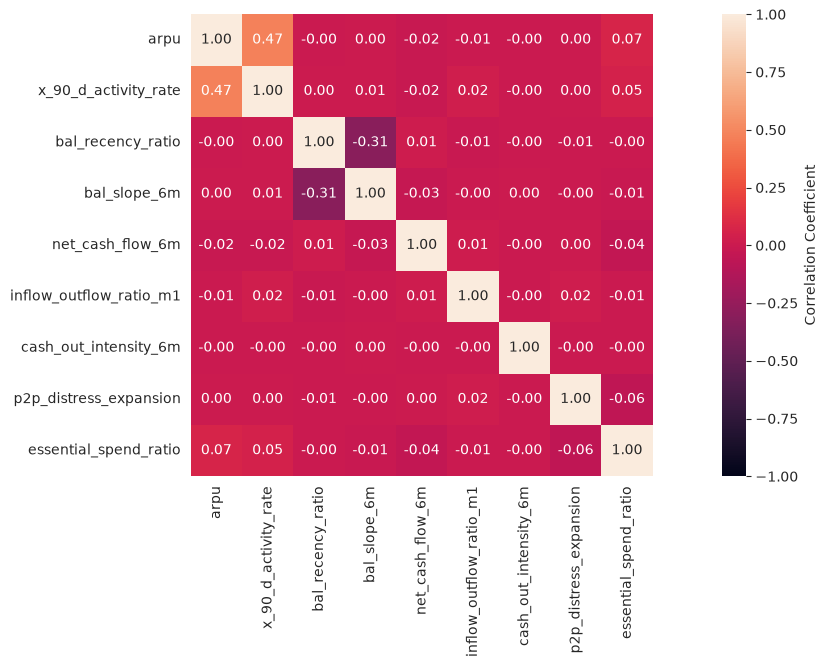

In [160]:
fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    features[feat_cols].corr(method='pearson'),
    annot=True,
      fmt='.2f',
      # cmap='coolwarm',
      vmin=-1,
      vmax=1,
      square=True,
      cbar_kws={'label': 'Correlation Coefficient'},
)

In [161]:
 calculate_vif(features, features.columns.to_list())

,Feature,VIF
0,avg_daily_bal_6m,4.936863
1,arpu,4.445825
2,x_90_d_activity_rate,4.297423
3,bal_recency_ratio,3.271207
4,bal_slope_6m,1.063624
5,essential_spend_ratio,1.014578
6,inflow_outflow_ratio_m1,1.009705
7,net_cash_flow_6m,1.003709
8,p2p_distress_expansion,1.003576
9,cash_out_intensity_6m,1.000065


In [162]:
# Try on existing model
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

In [163]:
# Identify the ID column, target column and feature columns
TARGET = "liquidity_stress_next_30d"
ID_COL = "ID"

def select_features(df):
    feature_cols = [c for c in df.columns if c not in [ID_COL, TARGET]]
    cat_cols = [c for c in feature_cols if df[c].dtype == "object" or df[c].dtype == "str"]
    
    return feat_cols, cat_cols


In [200]:
feature_cols, cat_cols = select_features(train_df)

In [201]:
train_df[cat_cols].head()

,gender,region,smartphone,segment,earning_pattern
0,F,Central Zone,Yes,MVC,Monthly Earner
1,F,Central Zone,Yes,MVC,Monthly Earner
2,F,Central Zone,Yes,MVC,Monthly Earner
3,F,Central Zone,Yes,MVC,Monthly Earner
4,F,Northern Highlands,No,MVC,Weekly Earner


In [223]:
def prepare_dataset(df, cat_cols, feature_cols):
    new_df = pd.concat([features, df[cat_cols]], axis=1)
    X_encoded = pd.get_dummies(new_df, columns=cat_cols, drop_first=True)

    for col in X_encoded.columns:
        median_value = X_encoded[col].median()
        X_encoded[col] = X_encoded[col].fillna(median_value)
    return X_encoded

In [224]:
X = prepare_dataset(train_df, cat_cols, feature_cols)
X.head(2)

,arpu,x_90_d_activity_rate,avg_daily_bal_6m,bal_recency_ratio,bal_slope_6m,net_cash_flow_6m,inflow_outflow_ratio_m1,cash_out_intensity_6m,p2p_distress_expansion,essential_spend_ratio,gender_M,region_Coastal & Eastern Corridor,region_Islander,region_Lake Zone (Northwest),region_Northern Highlands,region_Southern Highlands,region_Western Zone,smartphone_Yes,segment_LVC,segment_MVC,earning_pattern_Monthly Earner,earning_pattern_Weekly Earner
0,2653.88,0.6905,12431.301667,0.585019,1349.242000,728349.62,3.503699,0.166046,-2.0,0.000000,False,False,False,False,False,False,False,True,False,True,True,False
1,2653.88,0.6905,6991.738333,1.364749,-464.975714,-152988.34,1.096404,0.777561,-9.0,0.602046,False,False,False,False,False,False,False,True,False,True,True,False


In [225]:
X.isnull().sum()

arpu                                 0
x_90_d_activity_rate                 0
avg_daily_bal_6m                     0
bal_recency_ratio                    0
bal_slope_6m                         0
net_cash_flow_6m                     0
inflow_outflow_ratio_m1              0
cash_out_intensity_6m                0
p2p_distress_expansion               0
essential_spend_ratio                0
gender_M                             0
region_Coastal & Eastern Corridor    0
region_Islander                      0
region_Lake Zone (Northwest)         0
region_Northern Highlands            0
region_Southern Highlands            0
region_Western Zone                  0
smartphone_Yes                       0
segment_LVC                          0
segment_MVC                          0
earning_pattern_Monthly Earner       0
earning_pattern_Weekly Earner        0
dtype: int64

In [226]:
# Features and target
y = train_df[TARGET]

# Split into train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_val.shape


((32000, 22), (8000, 22))

In [227]:
print(f"Training with {X.shape[1]} encoded features.")


Training with 22 encoded features.


In [238]:
# Train a Logistic Regression model
pipeline = Pipeline([
    (
        "scaler", StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=100,
            class_weight="balanced",
            solver="lbfgs"
        )
    )
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['arpu','x_90_d_activity_rate','avg_daily_bal_6m',...,'segment_MVC', 'earning_pattern_Monthly Earner','earning_pattern_Weekly Earner']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [239]:
# Predict on validation set
val_pred_prob = pipeline.predict_proba(X_val)[:, 1]
val_pred_label = (val_pred_prob >= 0.5).astype(int)

# Evaluate
print("Validation ROC-AUC:", roc_auc_score(y_val, val_pred_prob))
print("\nClassification Report:")
print(classification_report(y_val, val_pred_label))


Validation ROC-AUC: 0.5410300857843137

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.54      0.67      6800
           1       0.17      0.54      0.26      1200

    accuracy                           0.54      8000
   macro avg       0.52      0.54      0.46      8000
weighted avg       0.76      0.54      0.60      8000



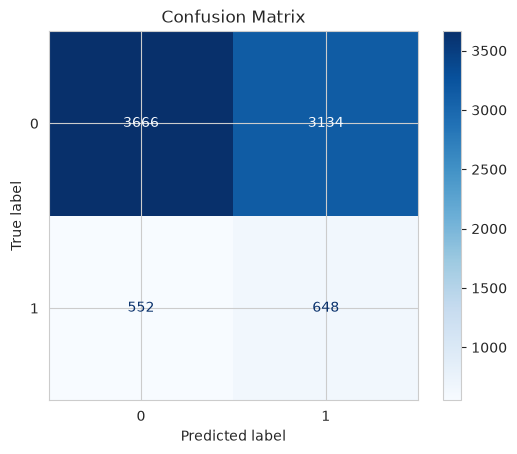

In [230]:
# 📈 Evaluate Model on Validation Set
cm = confusion_matrix(y_val, val_pred_label)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [233]:
from xgboost import XGBClassifier

# Train XGBoost on your engineered features
model = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=10, random_state=42
)
model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [234]:
# Predict on validation set
val_pred_prob = model.predict_proba(X_val)[:, 1]
val_pred_label = (val_pred_prob >= 0.5).astype(int)

# Evaluate
print("Validation ROC-AUC:", roc_auc_score(y_val, val_pred_prob))
print("\nClassification Report:")
print(classification_report(y_val, val_pred_label))

Validation ROC-AUC: 0.5190835784313725

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      6800
           1       0.00      0.00      0.00      1200

    accuracy                           0.85      8000
   macro avg       0.42      0.50      0.46      8000
weighted avg       0.72      0.85      0.78      8000



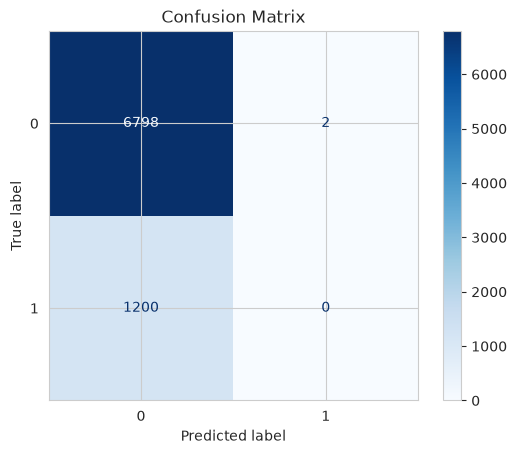

In [235]:
# 📈 Evaluate Model on Validation Set
cm = confusion_matrix(y_val, val_pred_label)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [177]:
X_train.columns

Index(['arpu', 'x_90_d_activity_rate', 'bal_recency_ratio', 'bal_slope_6m',
       'net_cash_flow_6m', 'inflow_outflow_ratio_m1', 'cash_out_intensity_6m',
       'p2p_distress_expansion', 'essential_spend_ratio', 'age', 'gender_M',
       'region_Coastal & Eastern Corridor', 'region_Islander',
       'region_Lake Zone (Northwest)', 'region_Northern Highlands',
       'region_Southern Highlands', 'region_Western Zone', 'smartphone_Yes',
       'segment_LVC', 'segment_MVC', 'earning_pattern_Monthly Earner',
       'earning_pattern_Weekly Earner'],
      dtype='str')

In [178]:
test_df = read_dataset("Test.csv")
test_df.head()

,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,m2_paybill_companies,m3_paybill_volume,m3_paybill_total_value,m3_paybill_highest_amount,m3_paybill_companies,m4_paybill_volume,m4_paybill_total_value,m4_paybill_highest_amount,m4_paybill_companies,m5_paybill_volume,m5_paybill_total_value,m5_paybill_highest_amount,m5_paybill_companies,m6_paybill_volume,m6_paybill_total_value,m6_paybill_highest_amount,m6_paybill_companies,m1_merchantpay_volume,m1_merchantpay_total_value,m1_merchantpay_highest_amount,m1_merchantpay_merchants,m2_merchantpay_volume,m2_merchantpay_total_value,m2_merchantpay_highest_amount,m2_merchantpay_merchants,m3_merchantpay_volume,m3_merchantpay_total_value,m3_merchantpay_highest_amount,m3_merchantpay_merchants,m4_merchantpay_volume,m4_merchantpay_total_value,m4_merchantpay_highest_amount,m4_merchantpay_merchants,m5_merchantpay_volume,m5_merchantpay_total_value,m5_merchantpay_highest_amount,m5_merchantpay_merchants,m6_merchantpay_volume,m6_merchantpay_total_value,m6_merchantpay_highest_amount,m6_merchantpay_merchants,m1_transfer_from_bank_volume,m1_transfer_from_bank_total_value,m1_transfer_from_bank_highest_amount,m1_transfer_from_bank_banks,m2_transfer_from_bank_volume,m2_transfer_from_bank_total_value,m2_transfer_from_bank_highest_amount,m2_transfer_from_bank_banks,m3_transfer_from_bank_volume,m3_transfer_from_bank_total_value,m3_transfer_from_bank_highest_amount,m3_transfer_from_bank_banks,m4_transfer_from_bank_volume,m4_transfer_from_bank_total_value,m4_transfer_from_bank_highest_amount,m4_transfer_from_bank_banks,m5_transfer_from_bank_volume,m5_transfer_from_bank_total_value,m5_transfer_from_bank_highest_amount,m5_transfer_from_bank_banks,m6_transfer_from_bank_volume,m6_transfer_from_bank_total_value,m6_transfer_from_bank_highest_amount,m6_transfer_from_bank_banks,m1_mm_send_volume,m1_mm_send_total_value,m1_mm_send_highest_amount,m1_mm_send_recipients,m2_mm_send_volume,m2_mm_send_total_value,m2_mm_send_highest_amount,m2_mm_send_recipients,m3_mm_send_volume,m3_mm_send_total_value,m3_mm_send_highest_amount,m3_mm_send_recipients,m4_mm_send_volume,m4_mm_send_total_value,m4_mm_send_highest_amount,m4_mm_send_recipients,m5_mm_send_volume,m5_mm_send_total_value,m5_mm_send_highest_amount,m5_mm_send_recipients,m6_mm_send_volume,m6_mm_send_total_value,m6_mm_send_highest_amount,m6_mm_send_recipients,m1_received_volume,m1_received_total_value,m1_received_highest_amount,m1_received_senders,m2_received_volume,m2_received_total_value,m2_received_highest_amount,m2_received_senders,m3_received_volume,m3_received_total_value,m3_received_highest_amount,m3_received_senders,m4_received_volume,m4_received_total_value,m4_received_highest_amount,m4_received_senders,m5_received_volume,m5_received_total_value,m5_received_highest_amount,m5_received_senders,m6_received_volume,m6_received_total_value,m6_received_highest_amount,m6_received_senders,m1_deposit_volume,m1_deposit_total_value,m1_deposit_highest_amount,m1_deposit_agents,m2_deposit_volume,m2_deposit_total_value,m2_deposit_highest_amount,m2_deposit_agents,m3_deposit_volume,m3_deposit_total_value,m3_deposit_highest_amount,m3_deposit_agents,m4_deposit_volume,m4_deposit_total_value,m4_deposit_highest_amount,m4_deposit_agents,m5_deposit_volume,m5_deposit_total_value,m5_deposit_highest_amount,m5_deposit_agents,m6_deposit_volume,m6_deposit_total_value,m6_deposit_highest_amount,m6_deposit_agents,m1_withdraw_volume,m1_withdraw_total_value,m1_withdraw_highest_amount,m1_withdraw_agents,m2_withdraw_volume,m2_withdraw_total_value,m2_withdraw_highest_amount,m2_withdraw_agents,m3_withdraw_volume,m3_withdraw_total_value,m3_withdraw_highest_amount,m3_withdraw_agents,m4_withdraw_volume,m4_withdraw_total_value,m4_withdraw_highest_amount,m4_withdraw_agents,m5_withdraw_volume,m5_withdraw_total_value,m5_withdraw_highe

In [179]:
features = Feature_Engineering_Pipeline(test_df)
features.head(2)

,arpu,x_90_d_activity_rate,avg_daily_bal_6m,bal_recency_ratio,bal_slope_6m,net_cash_flow_6m,inflow_outflow_ratio_m1,cash_out_intensity_6m,p2p_distress_expansion,essential_spend_ratio
0,2653.88,0.6905,12431.301667,0.585019,1349.242000,728349.62,3.503699,0.166046,-2.0,0.000000
1,2653.88,0.6905,6991.738333,1.364749,-464.975714,-152988.34,1.096404,0.777561,-9.0,0.602046


In [180]:
remove_unused_cols(features)

['arpu',
 'x_90_d_activity_rate',
 'bal_recency_ratio',
 'bal_slope_6m',
 'net_cash_flow_6m',
 'inflow_outflow_ratio_m1',
 'cash_out_intensity_6m',
 'p2p_distress_expansion',
 'essential_spend_ratio']

In [190]:
feature_cols, cat_cols = select_features(test_df)
X_test = prepare_dataset(test_df, cat_cols, feature_cols)
X_test.head(2)

,arpu,x_90_d_activity_rate,bal_recency_ratio,bal_slope_6m,net_cash_flow_6m,inflow_outflow_ratio_m1,cash_out_intensity_6m,p2p_distress_expansion,essential_spend_ratio,age,gender_M,region_Coastal & Eastern Corridor,region_Islander,region_Lake Zone (Northwest),region_Northern Highlands,region_Southern Highlands,region_Western Zone,smartphone_Yes,segment_LVC,segment_MVC,earning_pattern_Monthly Earner,earning_pattern_Weekly Earner
0,2653.88,0.6905,0.585019,1349.242000,728349.62,3.503699,0.166046,-2.0,0.000000,47,False,False,False,False,False,False,False,True,False,True,True,False
1,2653.88,0.6905,1.364749,-464.975714,-152988.34,1.096404,0.777561,-9.0,0.602046,47,False,False,False,False,False,False,False,True,False,True,True,False


In [191]:
X_test.select_dtypes("object")

,gender_M,region_Coastal & Eastern Corridor,region_Islander,region_Lake Zone (Northwest),region_Northern Highlands,region_Southern Highlands,region_Western Zone,smartphone_Yes,segment_LVC,segment_MVC,earning_pattern_Monthly Earner,earning_pattern_Weekly Earner
0,False,False,False,False,False,False,False,True,False,True,True,False
1,False,False,False,False,False,False,False,True,False,True,True,False
2,False,False,False,False,False,False,False,True,False,True,True,False
3,False,False,False,False,True,False,False,False,False,True,False,True
4,False,False,False,False,True,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
39995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
39996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
39997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
39998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


In [187]:
X_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   arpu                               30000 non-null  float64
 1   x_90_d_activity_rate               30000 non-null  float64
 2   bal_recency_ratio                  30000 non-null  float64
 3   bal_slope_6m                       30000 non-null  float64
 4   net_cash_flow_6m                   30000 non-null  float64
 5   inflow_outflow_ratio_m1            30000 non-null  float64
 6   cash_out_intensity_6m              30000 non-null  float64
 7   p2p_distress_expansion             30000 non-null  float64
 8   essential_spend_ratio              30000 non-null  float64
 9   age                                40000 non-null  int64  
 10  gender_M                           30000 non-null  object 
 11  region_Coastal & Eastern Corridor  30000 non-null  object 
 12  r

In [182]:
# Check that train and test feature columns match before predicting
assert list(X_test.columns) == list(X.columns)
print("Train and test feature columns match.")


Train and test feature columns match.


In [184]:
test_predictions =  model.predict_proba(X_test)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:gender_M: object, region_Coastal & Eastern Corridor: object, region_Islander: object, region_Lake Zone (Northwest): object, region_Northern Highlands: object, region_Southern Highlands: object, region_Western Zone: object, smartphone_Yes: object, segment_LVC: object, segment_MVC: object, earning_pattern_Monthly Earner: object, earning_pattern_Weekly Earner: object